## Tranfer Learning for multi class Image classification 

In [69]:
import torch
import torchvision
from torchinfo import summary
from torch import nn
from torchvision import transforms
import matplotlib.pyplot as plt

import sys
import os
from pathlib import Path

# Get the absolute path of the current directory
module_path = os.path.abspath(os.path.join('..'))

# Add the parent directory (project root) to sys.path
if module_path not in sys.path:
    sys.path.append(module_path)


from src.data_loader import create_dataloader
from src.engine import train_model

#### Get data

In [37]:
project_root = Path(os.getcwd()).parent

train_dir = project_root / "data/Subsampled_Plant_Dataset/train"
test_dir = project_root/ "data/Subsampled_Plant_Dataset/test"

#### creating datasets, dataloaders and transform for torchvision.models

In [40]:
#since we are using a pretrained model we must apply the same 
#data augmentation used to train the pretrained model.

weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT
weights


EfficientNet_B0_Weights.IMAGENET1K_V1

In [41]:
auto_transforms = weights.transforms()
auto_transforms

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)

In [42]:
train_dataloader, test_dataloder, class_names = create_dataloader(train_dir=train_dir,
                                                                  test_dir=test_dir,
                                                                  transform=auto_transforms,
                                                                  batch_size=32)
train_dataloader, test_dataloder, class_names

(<torch.utils.data.dataloader.DataLoader at 0x79f1c81c66f0>,
 ['Apple___Apple_scab',
  'Apple___Black_rot',
  'Apple___Cedar_apple_rust',
  'Apple___healthy',
  'Blueberry___healthy',
  'Cherry_(including_sour)___Powdery_mildew',
  'Cherry_(including_sour)___healthy',
  'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
  'Corn_(maize)___Common_rust_',
  'Corn_(maize)___Northern_Leaf_Blight',
  'Corn_(maize)___healthy',
  'Grape___Black_rot',
  'Grape___Esca_(Black_Measles)',
  'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
  'Grape___healthy',
  'Orange___Haunglongbing_(Citrus_greening)',
  'Peach___Bacterial_spot',
  'Peach___healthy',
  'Pepper,_bell___Bacterial_spot',
  'Pepper,_bell___healthy',
  'Potato___Early_blight',
  'Potato___Late_blight',
  'Potato___healthy',
  'Raspberry___healthy',
  'Soybean___healthy',
  'Squash___Powdery_mildew',
  'Strawberry___Leaf_scorch',
  'Strawberry___healthy',
  'Tomato___Bacterial_spot',
  'Tomato___Early_blight',
  'Tomato___Late_blight',


since this is used to train the model, we will use it to prepare our data


In [43]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [47]:
# get the pretrained model
# we will use EfficientNet_B0
weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT 
model = torchvision.models.efficientnet_b0(weights=weights).to(device)

In [61]:
summary(model=model, 
        input_size=(32, 3, 224, 224), 
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]
) 

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [32, 3, 224, 224]    [32, 38]             --                   Partial
├─Sequential (features)                                      [32, 3, 224, 224]    [32, 1280, 7, 7]     --                   False
│    └─Conv2dNormActivation (0)                              [32, 3, 224, 224]    [32, 32, 112, 112]   --                   False
│    │    └─Conv2d (0)                                       [32, 3, 224, 224]    [32, 32, 112, 112]   (864)                False
│    │    └─BatchNorm2d (1)                                  [32, 32, 112, 112]   [32, 32, 112, 112]   (64)                 False
│    │    └─SiLU (2)                                         [32, 32, 112, 112]   [32, 32, 112, 112]   --                   --
│    └─Sequential (1)                                        [32, 32, 112, 112]   [32, 

### NOTE:
* as you see in the model summary all the trainable params are true and there are more than 5 million parameters,
 which means if we train on this model directly, all weight will be updated.
 But the purpose of transfer learing is that we are going to use this trained weights as a base and train on top of them. so we will have to freeze some weights.  

### Freezing the base model and changing the output layer for our needs

We can freeze all of the layers/parameters in the `features` section by setting the attribute `requires_grad=False`.

In [62]:
# freeze all the base layers in the features section of the model
for param in model.features.parameters():
    param.requires_grad = False

In [64]:
summary(model=model, 
        input_size=(32, 3, 224, 224), 
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]
) 

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [32, 3, 224, 224]    [32, 38]             --                   Partial
├─Sequential (features)                                      [32, 3, 224, 224]    [32, 1280, 7, 7]     --                   False
│    └─Conv2dNormActivation (0)                              [32, 3, 224, 224]    [32, 32, 112, 112]   --                   False
│    │    └─Conv2d (0)                                       [32, 3, 224, 224]    [32, 32, 112, 112]   (864)                False
│    │    └─BatchNorm2d (1)                                  [32, 32, 112, 112]   [32, 32, 112, 112]   (64)                 False
│    │    └─SiLU (2)                                         [32, 32, 112, 112]   [32, 32, 112, 112]   --                   --
│    └─Sequential (1)                                        [32, 32, 112, 112]   [32, 

as you see the trainable parameters are `False`. meaning they are frozen and wont change during training but the output is still 1000.

In [65]:
# in our summary there are 1000 outputs bc therer are 1000 classes in ImageNet,
#  the dataset efficientnet_b0 is trained on, we will have to change that

torch.manual_seed(42)
torch.cuda.manual_seed(42)

# get the lenght our data class
num_in_features = model.classifier[1].in_features
num_output_shape  = len(class_names)

# reacreate the classifier layer and seed it to the target device
model.classifier = torch.nn.Sequential(
    torch.nn.Dropout(p=0.2, inplace=True),
    torch.nn.Linear(in_features=num_in_features,
                    out_features=num_output_shape,
                    bias=True)
).to(device)

In [66]:
summary(model=model, 
        input_size=(32, 3, 224, 224), 
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]
) 

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [32, 3, 224, 224]    [32, 38]             --                   Partial
├─Sequential (features)                                      [32, 3, 224, 224]    [32, 1280, 7, 7]     --                   False
│    └─Conv2dNormActivation (0)                              [32, 3, 224, 224]    [32, 32, 112, 112]   --                   False
│    │    └─Conv2d (0)                                       [32, 3, 224, 224]    [32, 32, 112, 112]   (864)                False
│    │    └─BatchNorm2d (1)                                  [32, 32, 112, 112]   [32, 32, 112, 112]   (64)                 False
│    │    └─SiLU (2)                                         [32, 32, 112, 112]   [32, 32, 112, 112]   --                   --
│    └─Sequential (1)                                        [32, 32, 112, 112]   [32, 

Now we have a frozen weights and the desired output shape :)

### Now lets train the model 

In [67]:
# we will use nn.CrossEntropyLoss() for loss funtion bc we are doing multi class
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model.parameters(), lr=0.01)

In [70]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

results = train_model(model=model,
                      train_dataloader=train_dataloader,
                      test_dataloader=test_dataloder,
                      loss_fn=loss_fn,
                      optimizer=optimizer,
                      epochs=15,
                      device=device
                      )

  7%|▋         | 1/15 [00:16<03:54, 16.78s/it]

Epoch: 1 | train_loss: 0.8455 | train_acc: 0.7652 | test_loss: 0.3496 | test_acc: 0.8863


 13%|█▎        | 2/15 [00:31<03:22, 15.56s/it]

Epoch: 2 | train_loss: 0.3373 | train_acc: 0.8958 | test_loss: 0.3074 | test_acc: 0.8972


 20%|██        | 3/15 [00:46<03:05, 15.43s/it]

...

Epoch: 13 | train_loss: 0.2137 | train_acc: 0.9478 | test_loss: 0.3690 | test_acc: 0.9212


 93%|█████████▎| 14/15 [03:41<00:15, 15.85s/it]

Epoch: 14 | train_loss: 0.2269 | train_acc: 0.9488 | test_loss: 0.3763 | test_acc: 0.9222


100%|██████████| 15/15 [03:56<00:00, 15.80s/it]

Epoch: 15 | train_loss: 0.2264 | train_acc: 0.9501 | test_loss: 0.4173 | test_acc: 0.9134


In [74]:
from src.utils import save_model
target_dir = "models"
model_name = "Plant disease classifier.pth"
save_model(model=model,
           target_dir=target_dir,
           model_name=model_name)

Saving modelto: models/Plant disease classifier.pth


In [78]:
def plot_loss_curves(results):
    loss = results["train_loss"]
    test_loss = results["test_loss"]

    accuracy = results["train_acc"]
    test_accuracy = results["test_acc"]

    epochs = range(len(results["train_loss"]))

    plt.figure(figsize=(15, 7))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, label="train_loss")
    plt.plot(epochs, test_loss, label="test_loss")
    plt.title("Loss")
    plt.xlabel("Epochs")
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, accuracy, label="train_accuracy")
    plt.plot(epochs, test_accuracy, label="test_accuracy")
    plt.title("Accuracy")
    plt.xlabel("Epochs")
    plt.legend()

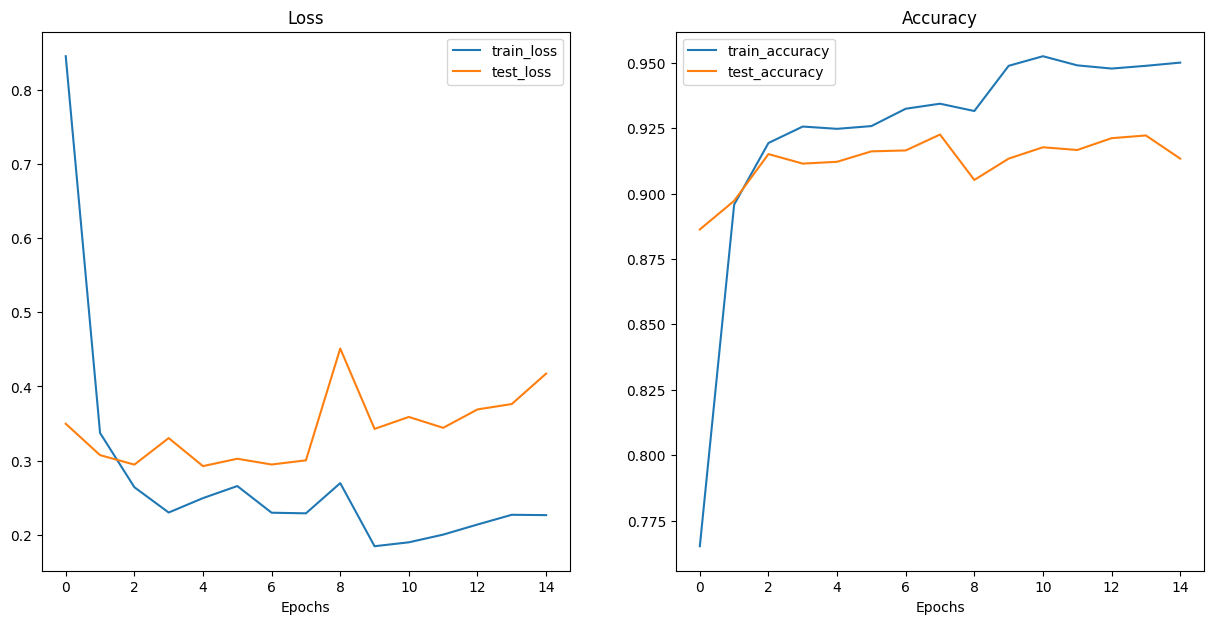

In [77]:
plot_loss_curves(results)